In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# LOAD DATA
# ============================================================

In [5]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)

In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df.shape

(53940, 10)

In [8]:
df.columns.tolist()

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

In [9]:
# ============================================================
# EDA & DATA QUALITY CHECK
# ============================================================

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [11]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [13]:
# Sentinel check: physically impossible zero dimensions
zero_dims = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"\nRows with x/y/z = 0: {len(zero_dims)}")
print(zero_dims)


Rows with x/y/z = 0: 20
       carat        cut color clarity  depth  table  price     x     y    z
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00  0.00  0.0
26123   2.25    Premium     I     SI1   61.3   58.0  15397  8.5

In [14]:
# Categorical columns unique values (need to check ordinal order)
print("\nCut categories:", df['cut'].unique())
print("Color categories:", df['color'].unique())
print("Clarity categories:", df['clarity'].unique())


Cut categories: ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
Color categories: ['E' 'I' 'J' 'H' 'F' 'G' 'D']
Clarity categories: ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [16]:
# Target distribution
print("\nPrice skewness:", df['price'].skew())


Price skewness: 1.618395283383529


In [17]:
# ============================================================
# PREPROCESSING
# ============================================================

In [18]:
# Drop physically impossible zero-dimension rows (sentinel/data error)
df = df[(df['x'] != 0) & (df['y'] != 0) & (df['z'] != 0)].reset_index(drop=True)
print(f"Shape after dropping zero-dimension rows: {df.shape}")

Shape after dropping zero-dimension rows: (53920, 10)


In [19]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [20]:
# Ordinal encoding for categorical columns (LightGBM native categorical support
# needs integer-coded categories with correct order embedded, not one-hot)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True).codes
df['color'] = pd.Categorical(df['color'], categories=color_order, ordered=True).codes
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True).codes

In [21]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53920 entries, 0 to 53919
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  int8   
 2   color    53920 non-null  int8   
 3   clarity  53920 non-null  int8   
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   x        53920 non-null  float64
 8   y        53920 non-null  float64
 9   z        53920 non-null  float64
dtypes: float64(6), int64(1), int8(3)
memory usage: 3.0 MB


In [22]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (43136, 9)
Test shape: (10784, 9)


In [25]:
# ============================================================
# BASELINE LIGHTGBM MODEL
# ============================================================

In [28]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [29]:
# Further split train into train/validation for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

cat_features = ['cut', 'color', 'clarity']

train_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print(f"\nBest iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 528.563
[200]	valid_0's rmse: 504.046
[300]	valid_0's rmse: 499.224
[400]	valid_0's rmse: 497.589
Early stopping, best iteration is:
[440]	valid_0's rmse: 496.98

Best iteration: 440


In [30]:
# ============================================================
# TEST SET METRICS
# ============================================================

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [32]:
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test R²: {r2:.4f}")

Test RMSE: 524.11
Test MAE: 269.08
Test R²: 0.9829


In [33]:
# Overfit check: compare train performance
y_pred_train = model.predict(X_tr, num_iteration=model.best_iteration)
train_rmse = np.sqrt(mean_squared_error(y_tr, y_pred_train))
print(f"\nTrain RMSE: {train_rmse:.2f}")
print(f"Overfit gap (RMSE): {rmse - train_rmse:.2f}")


Train RMSE: 425.46
Overfit gap (RMSE): 98.64


In [34]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

In [35]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(importance)

   feature    importance
7        y  3.032437e+12
0    carat  2.369094e+12
3  clarity  3.680680e+11
8        z  1.926411e+11
2    color  1.677395e+11
6        x  3.220897e+10
4    depth  1.280575e+10
1      cut  8.278266e+09
5    table  4.932036e+09


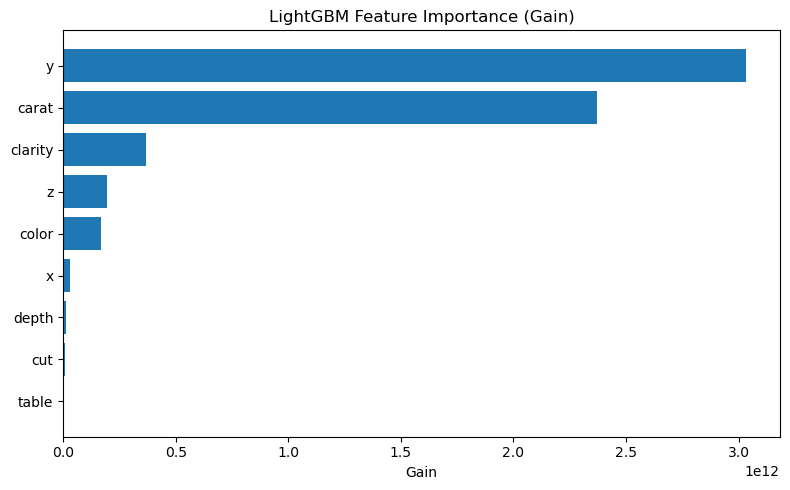

In [36]:
plt.figure(figsize=(8, 5))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Gain')
plt.title('LightGBM Feature Importance (Gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# CROSS-VALIDATION
# ============================================================

In [38]:
from sklearn.model_selection import KFold, cross_val_score

In [39]:
lgb_sklearn = lgb.LGBMRegressor(
    objective='regression',
    learning_rate=0.05,
    n_estimators=model.best_iteration,
    verbose=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lgb_sklearn, X_train, y_train,
    cv=kf, scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores
print(f"CV RMSE scores: {cv_rmse}")
print(f"CV RMSE mean: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

CV RMSE scores: [526.34416005 552.9182287  544.91367331 547.84653586 512.73456911]
CV RMSE mean: 536.95 ± 15.07
